In [1]:
import os
os.chdir("C:\\Users\karth\Karthik\Timmins\JUNE-MONTH-Training\Datasets")
os.getcwd()

'C:\\Users\\karth\\Karthik\\Timmins\\JUNE-MONTH-Training\\Datasets'

In [2]:
import pandas as pd

# Step 1: Read test data
df = pd.read_csv("wafer_test_data.csv")

print("Full Dataset:")
print(df)

# Step 2: Filter failed dies
failed_df = df[df['test_result'] == 'FAIL']

print("\nFailed Dies:")
print(failed_df)

# Step 3: Calculate Yield %
total_dies = len(df)
passed_dies = len(df[df['test_result'] == 'PASS'])

yield_percent = (passed_dies / total_dies) * 100

print(f"\nTotal Dies: {total_dies}")
print(f"Passed Dies: {passed_dies}")
print(f"Yield %: {yield_percent:.2f}%")

# Step 4: Summarize per wafer & lot

summary = df.groupby(['lot_id', 'wafer_id']).agg(
    total_dies=('die_id', 'count'),
    passed=('test_result', lambda x: (x == 'PASS').sum()),
    failed=('test_result', lambda x: (x == 'FAIL').sum())
).reset_index()

# Calculate yield per wafer
summary['yield_%'] = (summary['passed'] / summary['total_dies']) * 100

print("\nSummary per Wafer & Lot:")
print(summary)

Full Dataset:
     lot_id wafer_id die_id test_result  voltage  current
0   LOT1001      W01   D001        PASS      1.2      0.5
1   LOT1001      W01   D002        FAIL      1.1      0.8
2   LOT1001      W01   D005        PASS      1.3      0.6
3   LOT1001      W02   D003        PASS      1.2      0.4
4   LOT1001      W02   D006        FAIL      1.0      0.9
5   LOT1001      W02   D007        PASS      1.2      0.5
6   LOT1002      W03   D004        FAIL      1.0      0.9
7   LOT1002      W03   D008        PASS      1.1      0.6
8   LOT1002      W03   D009        PASS      1.2      0.5
9   LOT1002      W04   D010        FAIL      1.0      0.8
10  LOT1002      W04   D011        FAIL      1.1      0.7
11  LOT1002      W04   D012        PASS      1.3      0.6
12  LOT1003      W05   D013        PASS      1.2      0.5
13  LOT1003      W05   D014        PASS      1.2      0.4
14  LOT1003      W05   D015        FAIL      1.0      0.9
15  LOT1003      W06   D016        PASS      1.3      0.6


In [ ]:
# 

In [3]:
import pandas as pd

# Load data
df = pd.read_csv("machine_sensor_data.csv")

# Clean spaces in unit columns
df['pressure_unit'] = df['pressure_unit'].str.strip()

# -------------------------------
# Temperature Normalization → Celsius
# -------------------------------
def convert_temp(value, unit):
    if unit == 'C':
        return value
    elif unit == 'F':
        return (value - 32) * 5/9
    elif unit == 'K':
        return value - 273.15

df['temp_C'] = df.apply(lambda x: convert_temp(x['temperature'], x['temp_unit']), axis=1)

# -------------------------------
# Pressure Normalization → Pascal
# -------------------------------
def convert_pressure(value, unit):
    if unit == 'Pa':
        return value
    elif unit == 'kPa':
        return value * 1000
    elif unit == 'bar':
        return value * 100000
    elif unit == 'psi':
        return value * 6894.76

df['pressure_Pa'] = df.apply(lambda x: convert_pressure(x['pressure'], x['pressure_unit']), axis=1)

# -------------------------------
# Vibration Normalization → mm/s
# -------------------------------
def convert_vibration(value, unit):
    if unit == 'mm/s':
        return value
    elif unit == 'um/s':
        return value / 1000

df['vibration_mm_s'] = df.apply(lambda x: convert_vibration(x['vibration'], x['vibration_unit']), axis=1)

# -------------------------------
# Final Clean Dataset
# -------------------------------
normalized_df = df[['machine_id', 'process', 'temp_C', 'pressure_Pa', 'vibration_mm_s']]

print("\nNormalized Sensor Data:")
print(normalized_df)


Normalized Sensor Data:
  machine_id      process     temp_C  pressure_Pa  vibration_mm_s
0        M01      Etching  75.000000   101325.000             5.0
1        M02   Deposition  75.000000   101352.972             5.0
2        M03  Lithography  26.850000   120000.000             4.0
3        M04      Etching  80.000000   100000.000             4.5
4        M05   Deposition  60.000000    90000.000             6.0
5        M06  Lithography  16.850000   101325.000             5.5
6        M07      Etching  77.000000   103421.400             5.5
7        M08   Deposition  71.111111   110000.000             4.8
8        M09  Lithography  31.850000   110000.000             4.5


In [4]:
#  1. Detect abnormal machines
df[df['temp_C'] > 80]

,machine_id,process,temperature,temp_unit,pressure,pressure_unit,vibration,vibration_unit,temp_C,pressure_Pa,vibration_mm_s



Summary:
  machine_id  shift  total_chips  avg_yield  avg_efficiency
0        M01    Day         1020  96.076923       72.857143
1        M01  Night          450  95.555556       69.230769
2        M02    Day          600  95.000000       80.000000
3        M02  Night         1130  94.686520       80.714286
4        M03    Day         1420  97.182540       88.750000
5        M03  Night          650  95.384615       92.857143

Charts saved in output/charts/


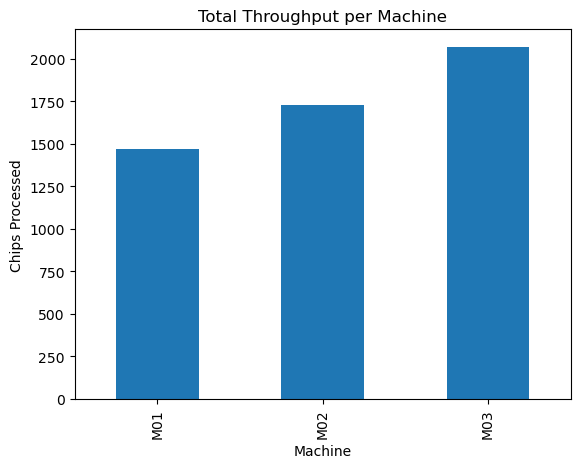

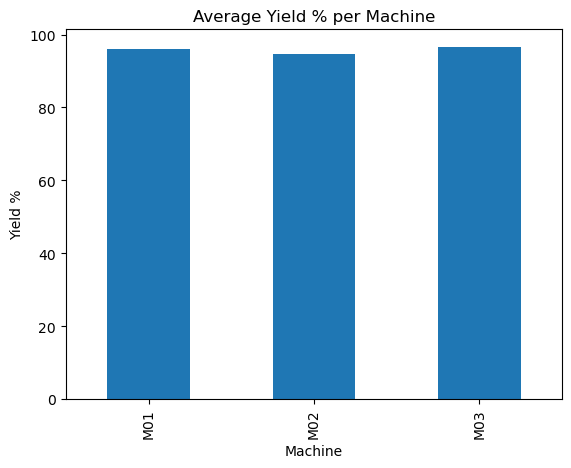

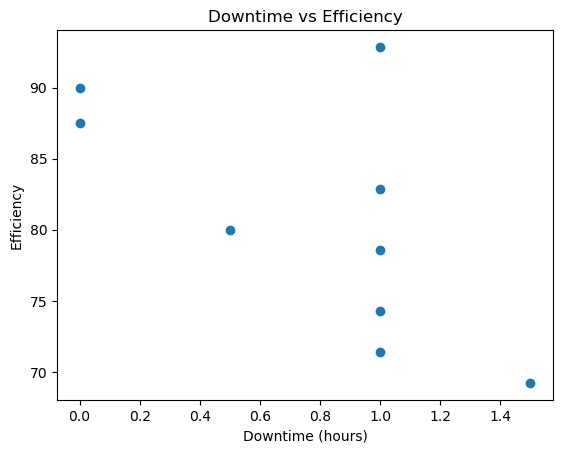

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load data
#df = pd.read_csv("data/production_data.csv")
df = pd.read_csv("production_data.csv")

# Create output folders
os.makedirs("output/charts", exist_ok=True)

# -------------------------------
# 1. Data Processing
# -------------------------------
df['yield_%'] = (df['good_chips'] / df['chips_processed']) * 100
df['efficiency'] = df['chips_processed'] / df['uptime_hours']

# -------------------------------
# 2. Summary Table
# -------------------------------
summary = df.groupby(['machine_id', 'shift']).agg(
    total_chips=('chips_processed', 'sum'),
    avg_yield=('yield_%', 'mean'),
    avg_efficiency=('efficiency', 'mean')
).reset_index()

print("\nSummary:")
print(summary)

# Save summary
summary.to_csv("output/summary.csv", index=False)

# -------------------------------
# 3. Visualization
# -------------------------------

# Chart 1: Throughput per Machine
throughput = df.groupby('machine_id')['chips_processed'].sum()

plt.figure()
throughput.plot(kind='bar')
plt.title("Total Throughput per Machine")
plt.xlabel("Machine")
plt.ylabel("Chips Processed")
plt.savefig("output/charts/throughput.png")

# Chart 2: Yield per Machine
yield_data = df.groupby('machine_id')['yield_%'].mean()

plt.figure()
yield_data.plot(kind='bar')
plt.title("Average Yield % per Machine")
plt.xlabel("Machine")
plt.ylabel("Yield %")
plt.savefig("output/charts/yield.png")

# Chart 3: Efficiency vs Downtime
plt.figure()
plt.scatter(df['downtime_hours'], df['efficiency'])
plt.title("Downtime vs Efficiency")
plt.xlabel("Downtime (hours)")
plt.ylabel("Efficiency")
plt.savefig("output/charts/downtime_vs_efficiency.png")

print("\nCharts saved in output/charts/")

In [13]:
import pandas as pd

# Load
df = pd.read_csv("cdr_raw.csv")

# Transform
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['duration_min'] = df['duration_sec'] / 60

# Aggregate
usage = df.groupby('caller').agg(
    total_calls=('caller', 'count'),
    total_duration=('duration_min', 'sum')
).reset_index()

# Save
usage.to_csv("cdr_summary.csv", index=False)

print("CDR Processing Done")

CDR Processing Done


In [14]:
print(open("cdr_summary.csv").read())

caller,total_calls,total_duration
9123456780,1,1.0
9876543210,2,7.0



In [ ]:
## tower_data.json - Activity

In [15]:
import pandas as pd

# Load JSON
df = pd.read_json("tower_data.json")

print("Raw Data:")
print(df)

# Data Transformation & Normalization
# Convert timestamp + normalize metrics
# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Normalize packet_loss → percentage
df['packet_loss_%'] = df['packet_loss'] * 100

# Normalize latency (optional scaling)
df['latency_ms'] = df['latency']

# Drop old column if needed
df = df.drop(columns=['packet_loss'])

print("\nTransformed Data:")
print(df)

# Filtering Data - Example: Identify bad network performance
# High latency or packet loss
alerts = df[(df['latency_ms'] > 40) | (df['packet_loss_%'] > 50)]

print("\nNetwork Alerts:")
print(alerts)

# Grouping & Summarization
summary = df.groupby('tower_id').agg(
    avg_latency=('latency_ms', 'mean'),
    max_latency=('latency_ms', 'max'),
    avg_packet_loss=('packet_loss_%', 'mean')
).reset_index()

print("\nTower Summary:")
print(summary)

# Convert Log Data → Structured Format
raw_logs = [
    "T1|2026-04-20 12:00|lat=30|loss=0.2",
    "T2|2026-04-20 12:00|lat=60|loss=0.7",
    "T3|2026-04-20 12:00|lat=20|loss=0.1"
]

log_data = []

for log in raw_logs:
    parts = log.split("|")
    record = {
        "tower_id": parts[0],
        "timestamp": parts[1],
        "latency": float(parts[2].split("=")[1]),
        "packet_loss": float(parts[3].split("=")[1])
    }
    log_data.append(record)

log_df = pd.DataFrame(log_data)

print("\nParsed Log Data:")
print(log_df)

# Save Clean Data
df.to_csv("clean_tower_data.csv", index=False)
summary.to_csv("tower_summary.csv", index=False)


report = {
    "total_records": len(df),
    "total_towers": df['tower_id'].nunique(),
    "avg_latency_overall": df['latency_ms'].mean(),
    "avg_packet_loss_overall": df['packet_loss_%'].mean(),
    "worst_tower": summary.sort_values('avg_latency', ascending=False).iloc[0]['tower_id']
}

print("\nEngineering Report:")
for k, v in report.items():
    print(f"{k}: {v}")

Raw Data:
   tower_id           timestamp  latency  packet_loss
0        T1 2026-04-20 10:00:00       20         0.10
1        T1 2026-04-20 11:00:00       25         0.15
2        T1 2026-04-20 12:00:00       30         0.20
3        T1 2026-04-20 13:00:00       28         0.18
4        T2 2026-04-20 10:00:00       50         0.50
5        T2 2026-04-20 11:00:00       55         0.60
6        T2 2026-04-20 12:00:00       60         0.70
7        T2 2026-04-20 13:00:00       58         0.65
8        T3 2026-04-20 10:00:00       15         0.05
9        T3 2026-04-20 11:00:00       18         0.08
10       T3 2026-04-20 12:00:00       22         0.10
11       T3 2026-04-20 13:00:00       20         0.09
12       T4 2026-04-20 10:00:00       70         1.20
13       T4 2026-04-20 11:00:00       75         1.50
14       T4 2026-04-20 12:00:00       80         1.80
15       T4 2026-04-20 13:00:00       78         1.60
16       T5 2026-04-20 10:00:00       35         0.30
17       T5 2026-0

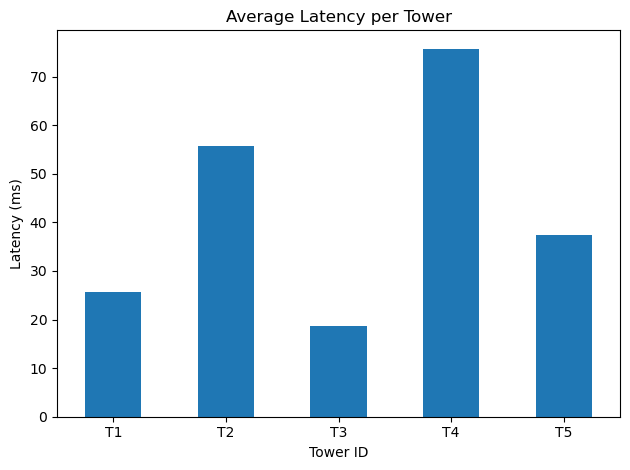

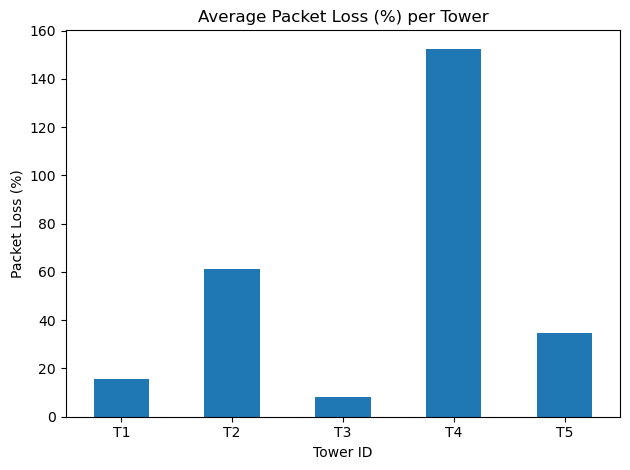

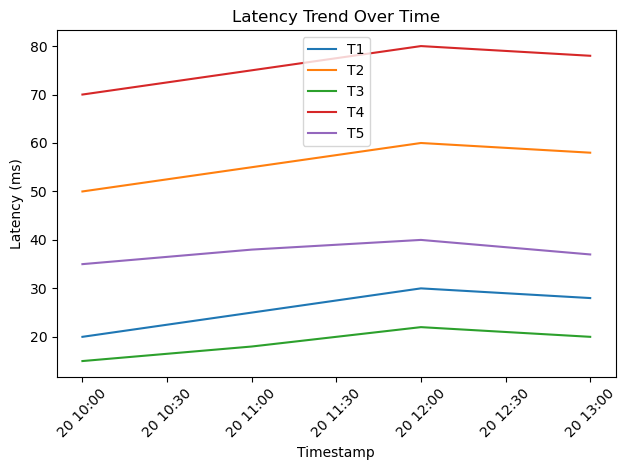

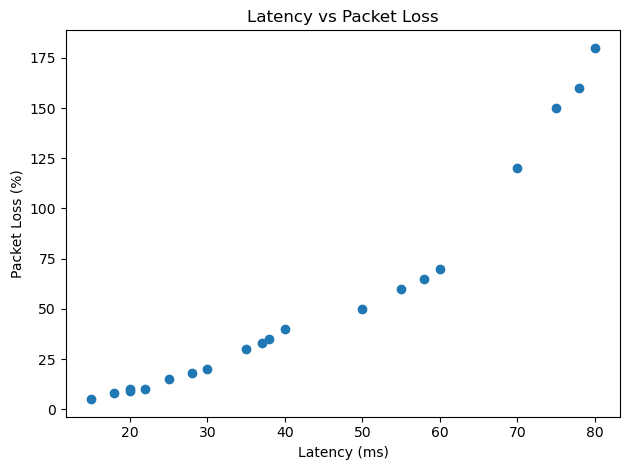

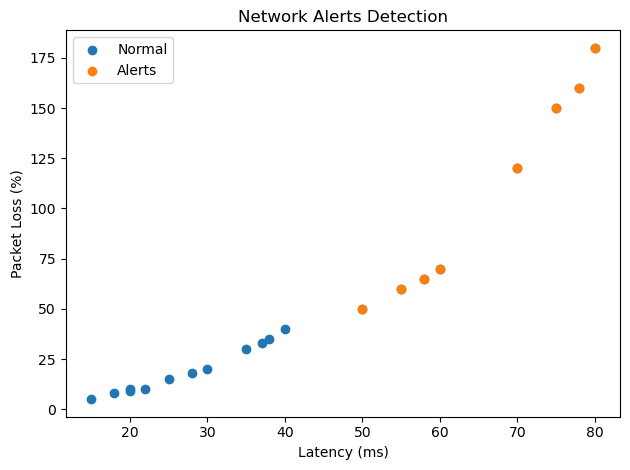

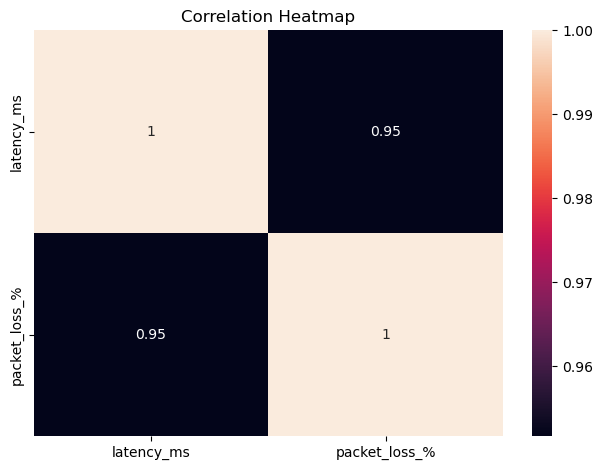


All charts saved in 'charts/' folder


In [16]:
# ===============================
# Visualization Section
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output folder
os.makedirs("charts", exist_ok=True)

# ----------------------------------
# 1. Average Latency per Tower (Bar Chart)
# ----------------------------------
plt.figure()
summary.set_index('tower_id')['avg_latency'].plot(kind='bar')
plt.title("Average Latency per Tower")
plt.xlabel("Tower ID")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/avg_latency_per_tower.png")
plt.show()

# ----------------------------------
# 2. Average Packet Loss per Tower
# ----------------------------------
plt.figure()
summary.set_index('tower_id')['avg_packet_loss'].plot(kind='bar')
plt.title("Average Packet Loss (%) per Tower")
plt.xlabel("Tower ID")
plt.ylabel("Packet Loss (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/packet_loss_per_tower.png")
plt.show()

# ----------------------------------
# 3. Time Series: Latency Trend
# ----------------------------------
plt.figure()
for tower in df['tower_id'].unique():
    subset = df[df['tower_id'] == tower]
    plt.plot(subset['timestamp'], subset['latency_ms'], label=tower)

plt.title("Latency Trend Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Latency (ms)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/latency_trend.png")
plt.show()

# ----------------------------------
# 4. Scatter Plot: Latency vs Packet Loss
# ----------------------------------
plt.figure()
plt.scatter(df['latency_ms'], df['packet_loss_%'])
plt.title("Latency vs Packet Loss")
plt.xlabel("Latency (ms)")
plt.ylabel("Packet Loss (%)")
plt.tight_layout()
plt.savefig("charts/latency_vs_packetloss.png")
plt.show()

# ----------------------------------
# 5. Alerts Visualization (Highlight Problem Points)
# ----------------------------------
plt.figure()
plt.scatter(df['latency_ms'], df['packet_loss_%'], label="Normal")
plt.scatter(alerts['latency_ms'], alerts['packet_loss_%'], label="Alerts")

plt.title("Network Alerts Detection")
plt.xlabel("Latency (ms)")
plt.ylabel("Packet Loss (%)")
plt.legend()
plt.tight_layout()
plt.savefig("charts/alerts.png")
plt.show()

# ----------------------------------
# 6. (Optional) Seaborn Heatmap (Correlation)
# ----------------------------------
plt.figure()
corr = df[['latency_ms', 'packet_loss_%']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/correlation.png")
plt.show()

print("\nAll charts saved in 'charts/' folder")

In [ ]:
# file: automation_kpi_monitor.py

In [18]:
import pandas as pd
import os
import glob
from datetime import datetime

# Folder paths
INPUT_FOLDER = "logs"
OUTPUT_FOLDER = "output"
LOG_FILE = "process.log"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Logging function
def log_message(message):
    with open(LOG_FILE, "a") as f:
        f.write(f"{datetime.now()} - {message}\n")

# Thresholds
LATENCY_THRESHOLD = 50
PACKET_LOSS_THRESHOLD = 1

all_alerts = []

try:
    # Step 1: Read all CSV files
    files = glob.glob(os.path.join(INPUT_FOLDER, "*.csv"))

    if not files:
        log_message("No files found!")
        print("No files to process.")
        exit()

    print(f"Processing {len(files)} files...\n")

    for file in files:
        try:
            print(f"Reading: {file}")
            df = pd.read_csv(file)

            # Step 2: Detect anomalies
            alerts = df[
                (df['latency_ms'] > LATENCY_THRESHOLD) |
                (df['packet_loss'] > PACKET_LOSS_THRESHOLD)
            ]

            if not alerts.empty:
                alerts['source_file'] = os.path.basename(file)
                all_alerts.append(alerts)

            log_message(f"Processed file: {file}")

        except Exception as e:
            log_message(f"Error processing {file}: {str(e)}")

    # Step 3: Combine all alerts
    if all_alerts:
        final_alerts = pd.concat(all_alerts)

        alert_file = os.path.join(
            OUTPUT_FOLDER,
            f"alerts_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
        )

        final_alerts.to_csv(alert_file, index=False)

        print("\n ALERTS DETECTED!")
        print(final_alerts)

        log_message(f"Alerts generated: {alert_file}")

    else:
        print("\n No issues detected.")
        log_message("No alerts found.")

except Exception as e:
    log_message(f"Critical error: {str(e)}")
    print("Script failed. Check logs.")

Processing 4 files...

Reading: logs\kpi_08.csv
Reading: logs\kpi_09.csv
Reading: logs\kpi_10.csv
Reading: logs\kpi_11.csv

⚠️ ALERTS DETECTED!
          timestamp tower_id  latency_ms  packet_loss  throughput_mbps  \
3  2026-04-20 08:00       T4          70          1.2               25   
6  2026-04-20 08:00       T7          80          1.5               20   
8  2026-04-20 08:00       T9          60          0.9               28   
3  2026-04-20 09:00       T4          75          1.4               22   
6  2026-04-20 09:00       T7          85          1.8               18   
8  2026-04-20 09:00       T9          65          1.0               26   
1  2026-04-20 10:00       T2          55          0.6               30   
3  2026-04-20 10:00       T4          80          1.5               20   
6  2026-04-20 10:00       T7          90          2.0               15   
8  2026-04-20 10:00       T9          70          1.2               24   
1  2026-04-20 11:00       T2          60  

C:\Users\karth\AppData\Local\Temp\ipykernel_33364\2641260998.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts['source_file'] = os.path.basename(file)
C:\Users\karth\AppData\Local\Temp\ipykernel_33364\2641260998.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts['source_file'] = os.path.basename(file)
C:\Users\karth\AppData\Local\Temp\ipykernel_33364\2641260998.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [1]:
! streamlit run app1.py

^C
